In [1]:
# -*- coding: utf-8 -*-

from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import numpy as np
import os 
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
# Path to load the data

# Amélie
link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

Episode:  0
Time | ep_step:  0 0


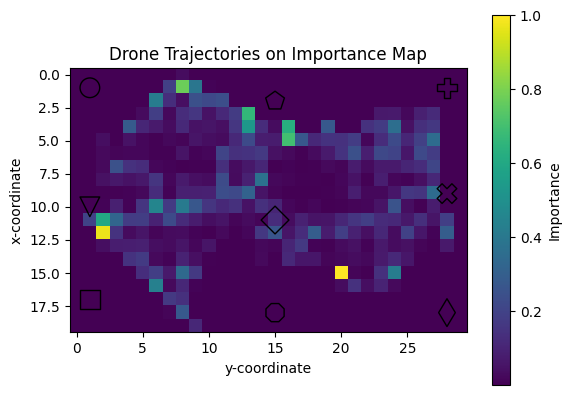

Time | ep_step:  1 1
Time | ep_step:  2 2
Time | ep_step:  3 3
Time | ep_step:  4 4
-----------
Episode:  1
Time | ep_step:  5 0
Time | ep_step:  6 1
Time | ep_step:  7 2
Time | ep_step:  8 3
Time | ep_step:  9 4
-----------
Episode:  2
Time | ep_step:  10 0
Time | ep_step:  11 1
Time | ep_step:  12 2
Time | ep_step:  13 3
Time | ep_step:  14 4
-----------
Episode:  3
Time | ep_step:  15 0
Time | ep_step:  16 1
Time | ep_step:  17 2
Time | ep_step:  18 3
Time | ep_step:  19 4
-----------
Episode:  4
Time | ep_step:  20 0
Time | ep_step:  21 1
Time | ep_step:  22 2
Time | ep_step:  23 3
Time | ep_step:  24 4
-----------
Episode:  5
Time | ep_step:  25 0
Time | ep_step:  26 1
Time | ep_step:  27 2
Time | ep_step:  28 3
Time | ep_step:  29 4
-----------
Episode:  6
Time | ep_step:  30 0
Time | ep_step:  31 1
Time | ep_step:  32 2
Time | ep_step:  33 3
Time | ep_step:  34 4
-----------
Episode:  7
Time | ep_step:  35 0
Time | ep_step:  36 1
Time | ep_step:  37 2
Time | ep_step:  38 3
Time 

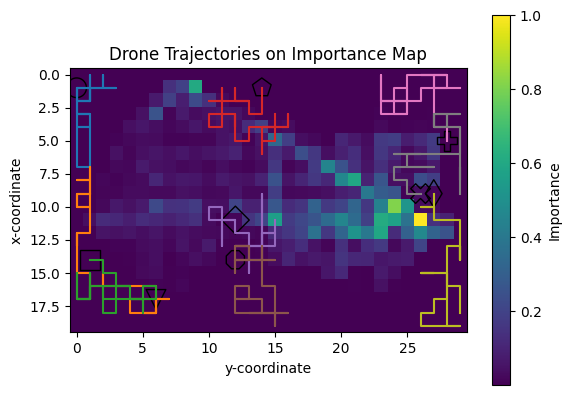

Time | ep_step:  51 1
Time | ep_step:  52 2
Time | ep_step:  53 3
Time | ep_step:  54 4
-----------
Episode:  11
Time | ep_step:  55 0
Time | ep_step:  56 1
Time | ep_step:  57 2
Time | ep_step:  58 3
Time | ep_step:  59 4
-----------
Episode:  12
Time | ep_step:  60 0
Time | ep_step:  61 1
Time | ep_step:  62 2
Time | ep_step:  63 3
Time | ep_step:  64 4
-----------
Episode:  13
Time | ep_step:  65 0
Time | ep_step:  66 1
Time | ep_step:  67 2
Time | ep_step:  68 3
Time | ep_step:  69 4
-----------
Episode:  14
Time | ep_step:  70 0
Time | ep_step:  71 1
Time | ep_step:  72 2
Time | ep_step:  73 3
Time | ep_step:  74 4
-----------
Episode:  15
Time | ep_step:  75 0
Time | ep_step:  76 1
Time | ep_step:  77 2
Time | ep_step:  78 3
Time | ep_step:  79 4
-----------
Episode:  16
Time | ep_step:  80 0
Time | ep_step:  81 1
Time | ep_step:  82 2
Time | ep_step:  83 3
Time | ep_step:  84 4
-----------
Episode:  17
Time | ep_step:  85 0
Time | ep_step:  86 1
Time | ep_step:  87 2
Time | ep_s

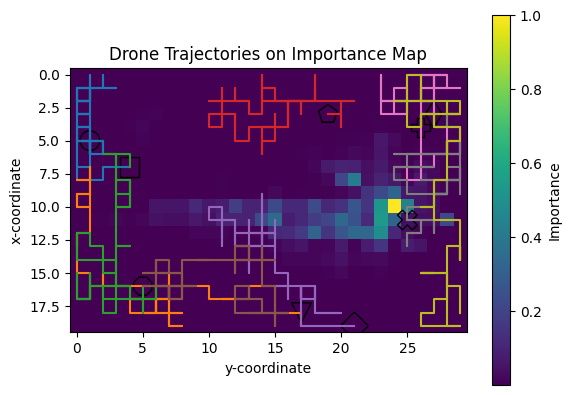

Time | ep_step:  101 1
Time | ep_step:  102 2
Time | ep_step:  103 3
Time | ep_step:  104 4
-----------
Episode:  21
Time | ep_step:  105 0
Time | ep_step:  106 1
Time | ep_step:  107 2
Time | ep_step:  108 3
Time | ep_step:  109 4
-----------
Episode:  22
Time | ep_step:  110 0
Time | ep_step:  111 1
Time | ep_step:  112 2
Time | ep_step:  113 3
Time | ep_step:  114 4
-----------
Episode:  23
Time | ep_step:  115 0
Time | ep_step:  116 1
Time | ep_step:  117 2
Time | ep_step:  118 3
Time | ep_step:  119 4
-----------
Episode:  24
Time | ep_step:  120 0
Time | ep_step:  121 1
Time | ep_step:  122 2
Time | ep_step:  123 3
Time | ep_step:  124 4
-----------
Episode:  25
Time | ep_step:  125 0
Time | ep_step:  126 1
Time | ep_step:  127 2
Time | ep_step:  128 3
Time | ep_step:  129 4
-----------


In [4]:
if __name__ == '__main__':

    N_episodes = 26
    ep_len     = 5
    
    buffer_size = 6000
    batch_size = 32
    
    # ----- Create a map -----
    
    x_size = 20
    y_size = 30
    
    list_of_small_pertb = [[0,4], [13,5], [17,25]]
    list_of_big_pert = [[6, 6], [6, 27], [18, 6], [18, 27]]
    
    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=['000'], load = True)
    Map.initialize_better_importance_map(id='pred_vtime')
    
    # ----- Create a fleet -----
    
    drone_init_pos = [[1,1], [10, 1], [17, 1], [2,15], [11,15], [18, 15], [1,28], [9,28], [18, 28]] 
  
    state_shape    = [ep_len, 13]    
 
    pretrained_folder = None    
    num_stacked = 1
    alpha = 1e-4
 
    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, lstm = False, gru = True, num_stacked = num_stacked, alpha = alpha) 
    F.add_drones(drone_init_pos)    
    
    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time
    if not os.path.exists(current_results):
        os.makedirs(current_results)     
    
    #----- Simultaion -----
    
    t_curr = 0
    
    ep_curr = 0 
    
    T = int(N_episodes * ep_len)
    
    while ep_curr < N_episodes:
        
        print('Episode: ',ep_curr)
        
        ep_step = 0
        
        while ep_step < ep_len:          
        
            # ------------------------------------------------------------------------------------------
            
            print('Time | ep_step: ', t_curr, ep_step)
            
            if t_curr % 50 == 0:
                F.plot_fleets_trajectories(t_curr, T, masked=True)
            
            if t_curr == 0:
            
                list_of_observations, list_of_drone_positions = F.get_fleet_info(t_curr, T)
                list_of_drone_states = F.get_drone_states(list_of_observations, list_of_drone_positions)
                visit_matrix = F.visit_matrix
                
                F.update_drone_state_history(list_of_drone_states)                   
                
            #------------- MOVE -------------------------------------------------------------------------------------
        
            list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.3, recover_param=0.025)

            #--------------------------------------------------------------------------------------------------------------------
            
            F.update_drone_action_history(list_of_actions)
            
            list_of_observations_, list_of_drone_positions_ = F.get_fleet_info(t_curr+1, T)
            list_of_drone_states_ = F.get_drone_states(list_of_observations_, list_of_drone_positions_)
            visit_matrix_ = F.visit_matrix
            
            F.update_drone_state_history(list_of_drone_states_)
            
            #----- Reward calculation -----
        
            list_of_rewards = F.get_reward(list_of_observations, list_of_observations_, visit_matrix, visit_matrix_, alpha1=1.0, alpha2=0.5)
            
            F.update_drone_reward_history(list_of_rewards)
            
            #----- Re-assign states for next iteration -----
        
            list_of_observations    = list_of_observations_
            list_of_drone_positions = list_of_drone_positions_
            list_of_drone_states    = list_of_drone_states_
        
            t_curr  += 1 
            ep_step +=1

        #----- Store transitions in the buffer -----
            
        ep_curr += 1
        
        print("-----------")
    
    F.create_data_set()
    
    F.buffer.save(current_results)
     

In [5]:
Map.importance_map.shape

(131, 20, 30)

In [6]:
list_of_perc_lstm = np.load(r'C:\Users\orane\Documents\GitHub\Projet-CE-1\FAKE DATA\Results\11_20_2024_02_07_05\action_memory.npy')
list_of_perc_gru = np.load(r'C:\Users\orane\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_09_2025_16_17_58 pretrain GRU ld_speed\action_memory.npy')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\orane\\Documents\\GitHub\\Projet-CE-1\\FAKE DATA\\Results\\11_20_2024_02_07_05\\action_memory.npy'

In [ ]:
len(list_of_perc_lstm)


6000

In [ ]:
list_of_perc_lstm[-20:]


array([[4.],
       [2.],
       [0.],
       [1.],
       [3.],
       [2.],
       [1.],
       [0.],
       [3.],
       [0.],
       [4.],
       [4.],
       [2.],
       [3.],
       [1.],
       [0.],
       [2.],
       [4.],
       [3.],
       [0.]])

In [ ]:
def count_nonzero_until_last(list_of_perc_gru):
    """
    Compte les éléments non-nuls dans un vecteur colonne,
    en ignorant uniquement les zéros à la fin.
    """
    # Aplatir au cas où l'array est de forme (n, 1)
    flat_array = list_of_perc_gru.flatten()

    # Trouver l'indice du dernier élément non nul
    nonzero_indices = np.nonzero(flat_array)[0]
    if len(nonzero_indices) == 0:
        return 0  # Tous les éléments sont nuls

    last_nonzero_idx = nonzero_indices[-1]

    # Compter les éléments jusqu’au dernier non-zéro (inclus)
    return last_nonzero_idx + 1

In [ ]:
count_nonzero_until_last(list_of_perc_gru)

1134